In [1]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
import datetime as dt
from datetime import datetime
import os
import kagglehub

# Change directory to the data location
os.chdir('../../ml_data')

# Read the data
df = pd.read_csv('credit_card_fraud_dataset.csv')
df

/Users/davidal-gurnawi/Documents/data_science/machine_learning/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0
...,...,...,...,...,...,...,...
99995,99996,2024-06-07 00:57:36.027591,1057.29,289,refund,San Antonio,0
99996,99997,2023-10-22 23:12:36.027594,297.25,745,refund,San Antonio,0
99997,99998,2024-05-31 19:27:36.027597,3448.56,690,purchase,San Antonio,0
99998,99999,2024-10-18 09:43:36.027601,3750.79,644,purchase,Philadelphia,0


In [2]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['Year'] = df.TransactionDate.dt.year
df['month'] = df.TransactionDate.dt.month 
df['day'] = df.TransactionDate.dt.day 
df['hour'] = df.TransactionDate.dt.hour
holidays = ["2023-01-02", "2023-01-16", "2023-05-29", "2023-06-19", "2023-07-04", "2023-09-04", "2023-11-10", "2023-11-23", "2023-12-25", "2024-01-01", "2024-01-15", "2024-05-27", "2024-06-19", "2024-07-04", "2024-09-02", "2024-11-11", "2024-11-24", "2024-12-25"]
date_format = '%Y-%m-%d %H:%M:%S'
# let's get them into a date time format
for i in range(len(holidays)):
    holidays[i] = datetime
# Then let's add a holiday classifier column

df['holidays'] = np.where(df['TransactionDate'].isin(holidays), 1, 0)
df['day_of_week'] = df['TransactionDate'].dt.day_of_week
df['weekends'] = np.where(df['TransactionDate'].dt.day_of_week.isin([6,7]), 1, 0)
df['business_day'] = np.where(((df['holidays']==1) & (df['weekends'] == 1)), 0, 1)

In [3]:
df.head()

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud,Year,month,day,hour,holidays,day_of_week,weekends,business_day
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0,2024,4,3,14,0,2,0,1
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0,2024,3,19,13,0,1,0,1
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0,2024,1,8,10,0,0,0,1
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0,2024,4,13,23,0,5,0,1
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0,2024,7,12,18,0,4,0,1


<Axes: xlabel='Location', ylabel='Count'>

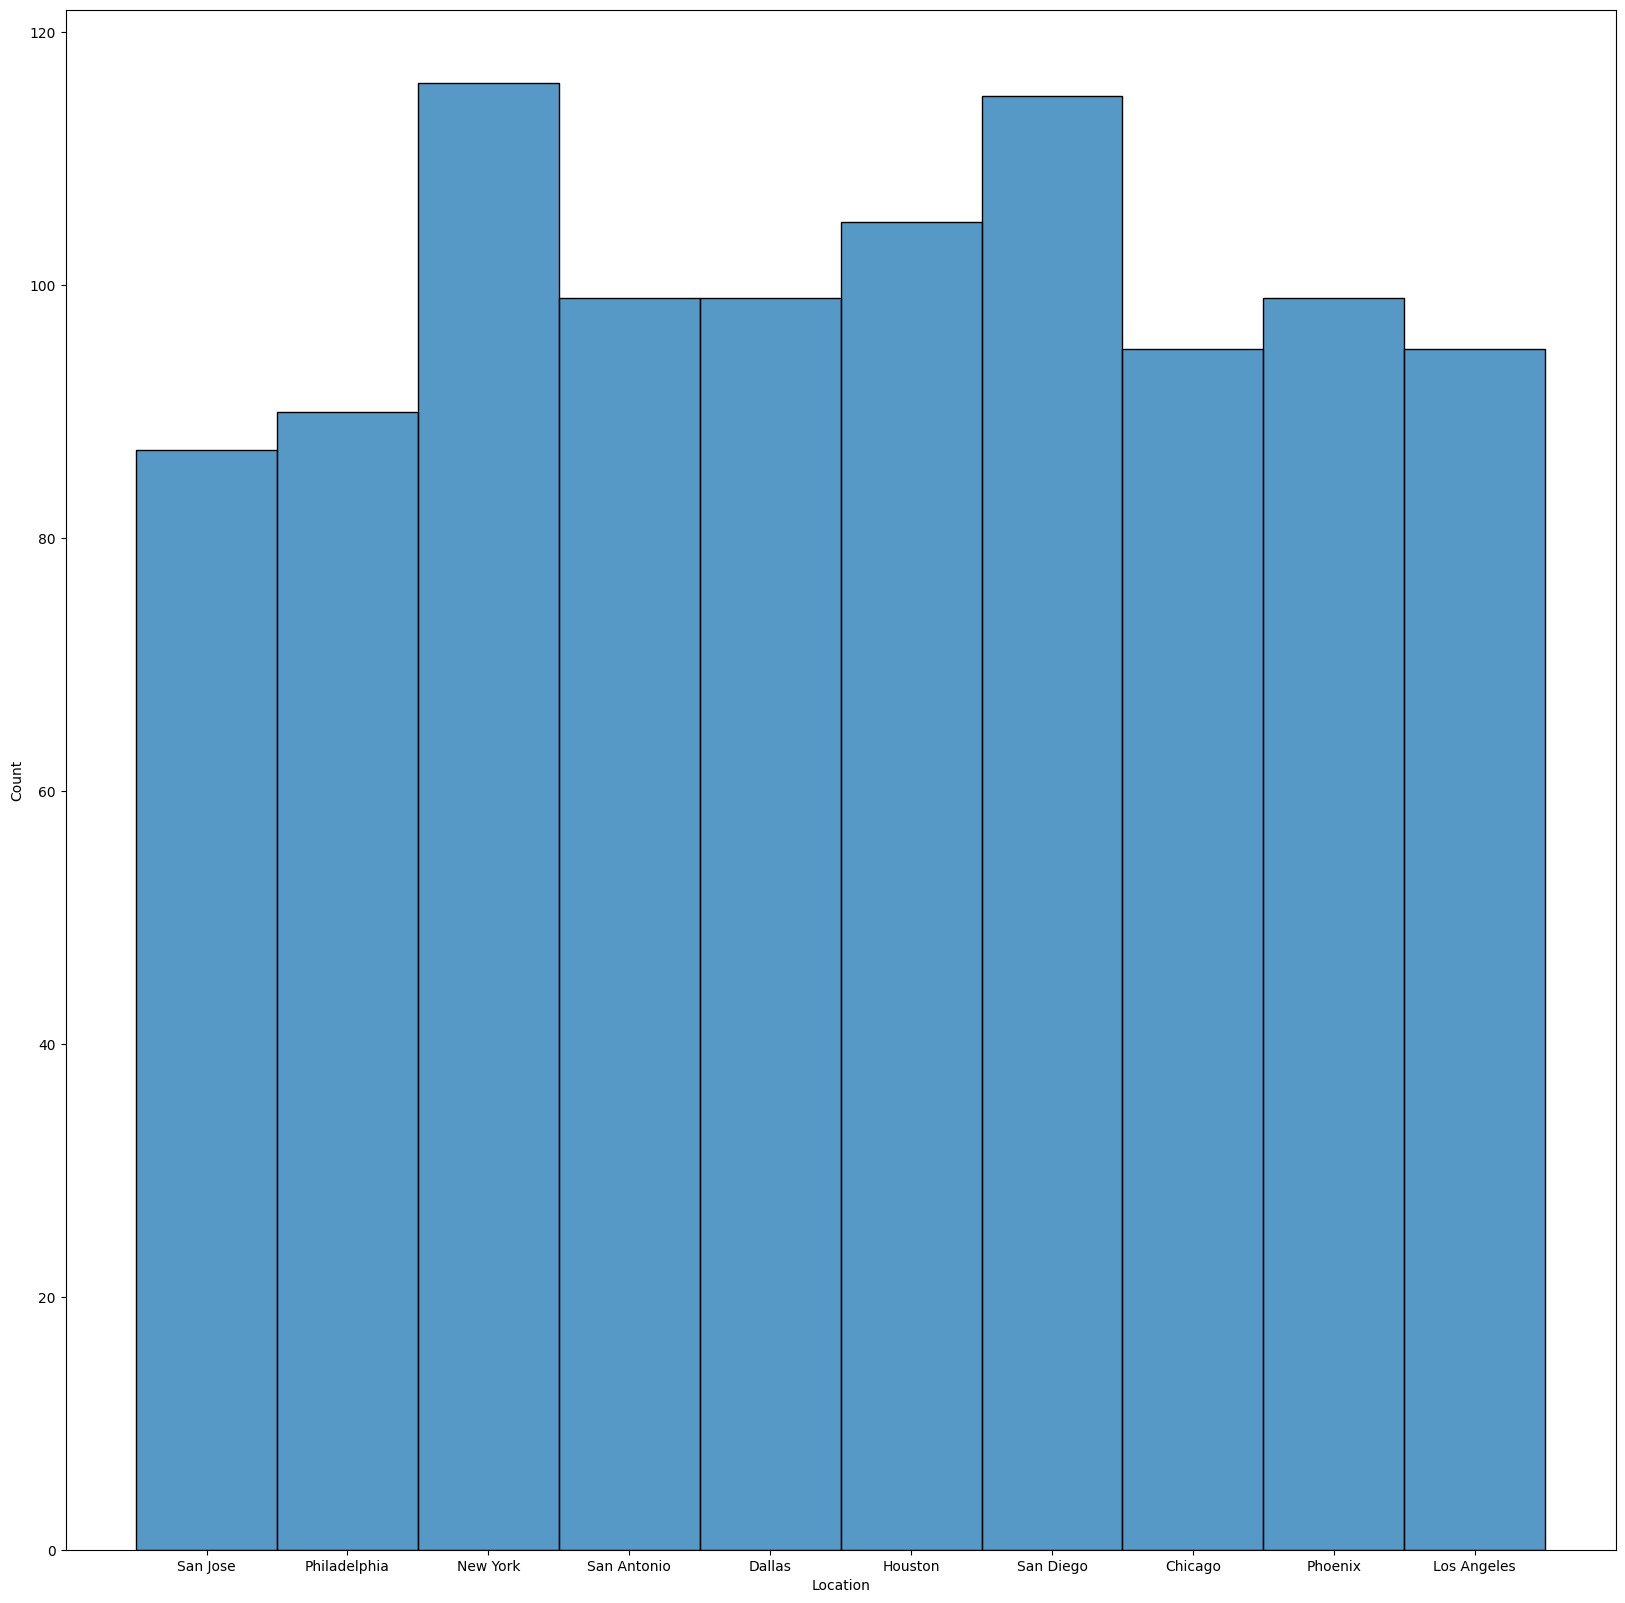

In [4]:
fig, axes = plt.subplots(1, 1, figsize=(20, 20), sharey=True)
#axes.set_xlim(-0.5, 6.5)
sns.histplot(df[df['IsFraud']==1], x='Location', discrete=True, multiple='dodge')


In [5]:
# The cities listed above, vary greatly in size, as a result it may not be truly representative
# of the actual fraud rates

In [16]:
pop = pd.read_csv('city_data.csv')
pop.head()

,Location,Population
0,San Jose,943212
1,Philadelphia,1517114
2,New York,8097282
3,San Antonio,1532653
4,Dallas,1302638


In [37]:
city_count = pd.pivot_table(df, index='Location', columns='IsFraud', values='TransactionID', aggfunc='count', margins=False).reset_index()
city_count = city_count.rename(columns={0:'NotFraud', 1:'Fraud'})
city_count

IsFraud,Location,NotFraud,Fraud
0,Chicago,10098,95
1,Dallas,9977,99
2,Houston,9886,105
3,Los Angeles,9841,95
4,New York,9877,116
5,Philadelphia,9783,90
6,Phoenix,9861,99
7,San Antonio,9963,99
8,San Diego,9996,115
9,San Jose,9718,87


In [27]:
city_count.columns

Index([0, 1], dtype='int64', name='IsFraud')

In [38]:
city_count = pd.merge(city_count, pop, on='Location')
city_count

,Location,NotFraud,Fraud,Population
0,Chicago,10098,95,2746388
1,Dallas,9977,99,1302638
2,Houston,9886,105,2390125
3,Los Angeles,9841,95,3878704
4,New York,9877,116,8097282
5,Philadelphia,9783,90,1517114
6,Phoenix,9861,99,1675144
7,San Antonio,9963,99,1532653
8,San Diego,9996,115,1404452
9,San Jose,9718,87,943212


In [40]:
city_count['per_100k']=round((city_count['Fraud']/city_count['Population'])*100000)
city_count

,Location,NotFraud,Fraud,Population,per_100k
0,Chicago,10098,95,2746388,3.0
1,Dallas,9977,99,1302638,8.0
2,Houston,9886,105,2390125,4.0
3,Los Angeles,9841,95,3878704,2.0
4,New York,9877,116,8097282,1.0
5,Philadelphia,9783,90,1517114,6.0
6,Phoenix,9861,99,1675144,6.0
7,San Antonio,9963,99,1532653,6.0
8,San Diego,9996,115,1404452,8.0
9,San Jose,9718,87,943212,9.0


In [42]:
# This completely changes the picture. Before the Fraud cases were by and large 
# on par. Now it shows that San Jose, San Diego, and Dallas seem to have higher instances 
# of fraud

In [41]:
city_count.to_csv('fraud_rates_city.csv', index=False)